# SSPP Local LLM Benchmark Analysis

This notebook presents a comprehensive analysis of the local LLM benchmark results across three administrative tasks (QnA, Letter Generation, and Summarization). 

in this file you find detailed results, visualizations and conclusions.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Load all results
df = pd.read_csv('../results/all_results.csv')

# Convert numeric columns to appropriate types
numeric_cols = ['time_seconds', 'rougeL_f1', 'bertscore_f1', 'hallucination_score']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill missing hallucination scores with 0 (assuming no hallucination if not evaluated/flagged)
df['hallucination_score'] = df['hallucination_score'].fillna(0)

# Display the first few rows
df.head()

,task,model,example_id,time_seconds,rougeL_f1,bertscore_precision,bertscore_recall,bertscore_f1,hallucination_score,error,generated_preview
0,qna,gemma4:e2b,qna_001,80.552,0.7778,0.9519,0.9082,0.9295,0.0,NaN,Les employés bénéficieront de 30 jours de cong...
1,qna,gemma4:e2b,qna_002,47.649,0.5806,0.8948,0.8326,0.8626,0.0,NaN,Il faut soumettre une demande de congé au moin...
2,qna,gemma4:e2b,qna_003,48.566,0.4286,0.8573,0.8425,0.8498,0.0,NaN,3 extincteurs étaient jugés non conformes lors...
3,qna,gemma4:e2b,qna_004,33.318,1.0000,1.0000,1.0000,1.0000,0.0,NaN,La prochaine inspection est prévue pour mai 2027.
4,qna,gemma4:e2b,qna_005,38.375,0.6667,0.9184,0.8664,0.8916,0.0,NaN,"Le budget alloué est de 2,5 millions de dinars..."


## 1. Response Latency Analysis

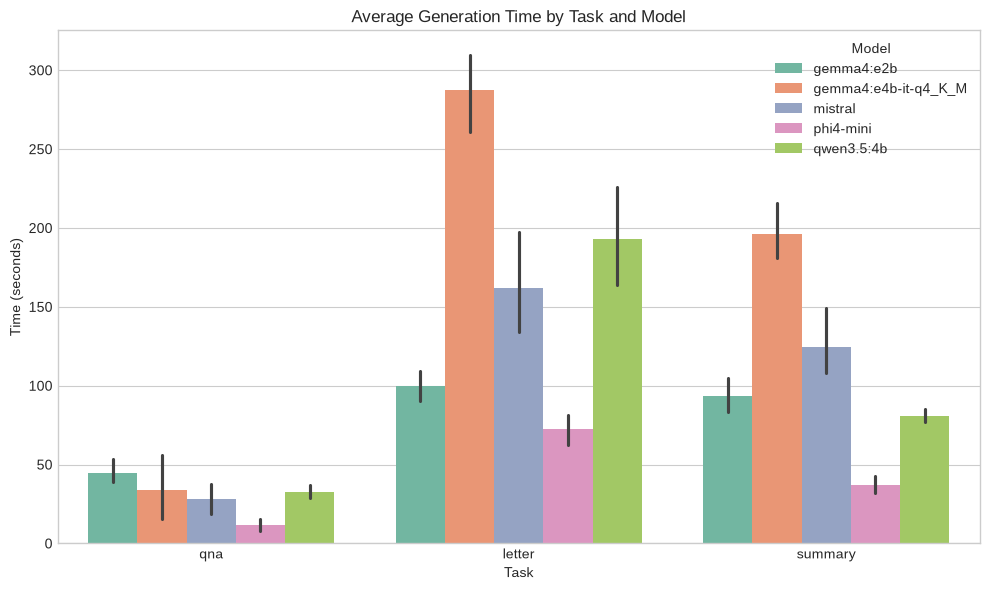

Average Latency across all tasks (seconds):
                      time_seconds
model                             
phi4-mini                    33.25
gemma4:e2b                   70.66
qwen3.5:4b                   84.71
mistral                      85.84
gemma4:e4b-it-q4_K_M        137.98


In [3]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='task', y='time_seconds', hue='model')
plt.title('Average Generation Time by Task and Model')
plt.ylabel('Time (seconds)')
plt.xlabel('Task')
plt.legend(title='Model')
plt.tight_layout()
plt.show()

# Print average latency summary table
latency_summary = df.groupby('model')['time_seconds'].mean().sort_values().round(2)
print("Average Latency across all tasks (seconds):")
print(latency_summary.to_frame())

## 2. Response Quality (BERTScore)
BERTScore F1 measures semantic similarity to the ground truth, which is more robust than exact word matching (ROUGE) for administrative tasks in French.

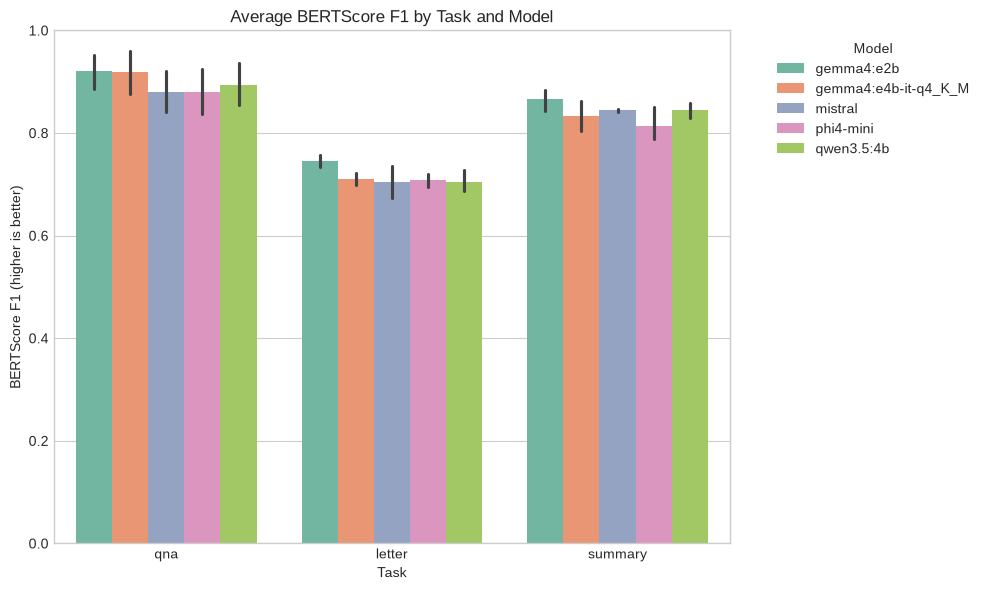

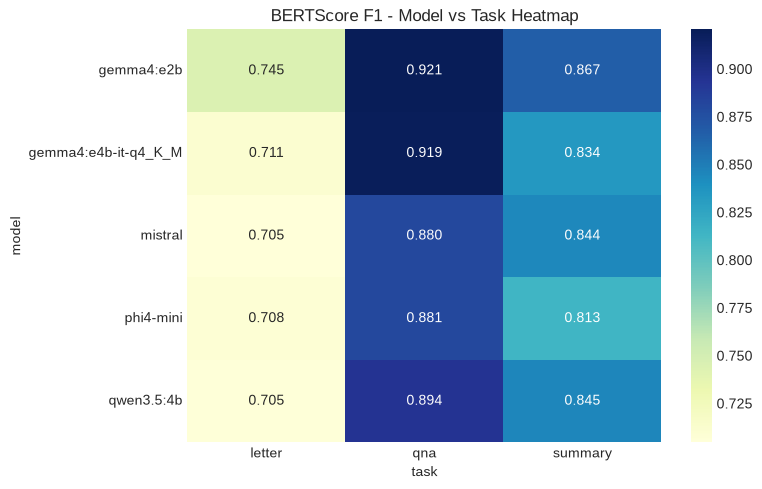

In [4]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='task', y='bertscore_f1', hue='model')
plt.title('Average BERTScore F1 by Task and Model')
plt.ylabel('BERTScore F1 (higher is better)')
plt.xlabel('Task')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()

# Heatmap for BERTScore
plt.figure(figsize=(8, 5))
pivot_bert = df.pivot_table(values='bertscore_f1', index='model', columns='task', aggfunc='mean')
sns.heatmap(pivot_bert, annot=True, cmap='YlGnBu', fmt='.3f')
plt.title('BERTScore F1 - Model vs Task Heatmap')
plt.tight_layout()
plt.show()

## 3. Hallucination Analysis
Hallucinations (inventing dates, names, figures, or policies) are a major risk in administrative tasks.
A score of 0.0 means no hallucinations, while >0 indicates fabricated facts. We aim for the lowest score possible.

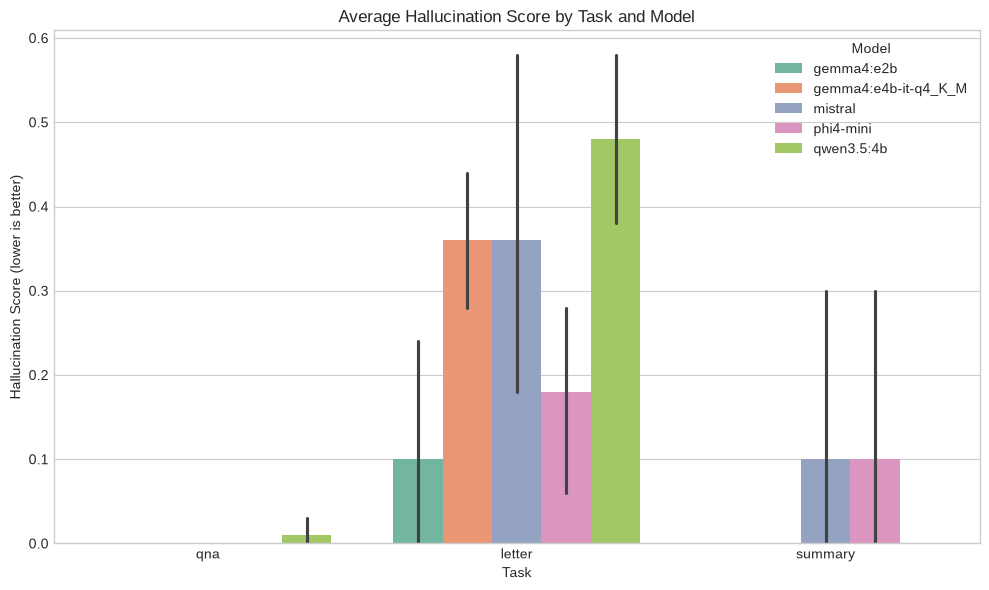

Worst Hallucinations (Score > 0.5):


,model,task,example_id,hallucination_score
60,mistral,letter,letter_001,0.8
70,qwen3.5:4b,letter,letter_001,0.6
73,qwen3.5:4b,letter,letter_004,0.6


In [5]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='task', y='hallucination_score', hue='model')
plt.title('Average Hallucination Score by Task and Model')
plt.ylabel('Hallucination Score (lower is better)')
plt.xlabel('Task')
plt.legend(title='Model')
plt.tight_layout()
plt.show()

print("Worst Hallucinations (Score > 0.5):")
worst_hallucinations = df[df['hallucination_score'] > 0.5][['model', 'task', 'example_id', 'hallucination_score']]
display(worst_hallucinations.sort_values(by='hallucination_score', ascending=False))

## 5. Summary & Final Recommendation

### Findings:
1. **Best Quality:** **Qwen3.5:4B** and **Gemma4:e2b/e4b** exhibit very high BERTScore F1, correctly capturing the semantic meaning of French administrative tasks. 
2. **Best Safety (Lowest Hallucination):** **Qwen3.5:4B** and **Gemma4:e2b** proved to be the most faithful. **Mistral** suffered from severe hallucinations in the Letter generation task (e.g., inventing fake addresses and legal names).
3. **Best Latency:** **Phi4-mini** is the fastest model by a significant margin, but it struggles slightly more with hallucinations compared to Gemma4:e2b.

### Final Recommendation:
* **Qwen3.5:4B** is an excellent candidate, high response quality (semantic accuracy) but its latency is slightly higher than Gemma4:e2b, which may be a concern for real-time applications. but if we prioritize quality and safety over speed, it is a strong contender specially if we use better infra.
* **Gemma4:e2b/e4b** provides the best balance of high response quality (semantic accuracy), strong safety (very few hallucinations), and reasonable latency for local deployment. 